In [1]:
import pandas as pd
import numpy as no
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf

base_dir = r"C:\Users\User\Desktop\usm\self learning\peneumonia detection\chest_xray"

train_dir = base_dir + r"\train"
test_dir  = base_dir + r"\test"

img_size = (224, 224)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"   # NORMAL vs PNEUMONIA
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, epochs=10, validation_data=test_data)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 840s 5s/step - accuracy: 0.9230 - loss: 0.2704 - val_accuracy: 0.8878 - val_loss: 0.3295
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 976s 6s/step - accuracy: 0.9673 - loss: 0.0952 - val_accuracy: 0.7740 - val_loss: 0.8265
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 826s 5s/step - accuracy: 0.9826 - loss: 0.0528 - val_accuracy: 0.8269 - val_loss: 0.7325
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 854s 5s/step - accuracy: 0.9889 - loss: 0.0301 - val_accuracy: 0.7901 - val_loss: 1.0473
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 839s 5s/step - accuracy: 0.9935 - loss: 0.0216 - val_accuracy: 0.8221 - val_loss: 0.9065
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 862s 5s/step - accuracy: 0.9987 - loss: 0.0065 - val_accuracy: 0.7933 - val_loss: 1.4962
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1434s 9s/step - accuracy: 0.9979 - loss: 0.0071 - val_accuracy: 0.8333 - val_loss: 0.9350
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1041s 6s/step - accuracy: 0.9979 - loss: 0.0063 - val_ac

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy())

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 992ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confusion Matrix:
[[ 87 147]
 [  1 389]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.37      0.54       234
   PNEUMONIA       0.73      1.00      0.84       390

    accuracy                           0.76     

In [11]:
# Threshold tuning

y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    y_pred.extend((preds > 0.75).astype(int).flatten())
    y_true.extend(labels.numpy())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 859ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
[[ 96 138]
 [  2 388]]
              precision    recall  f1-score   support

      NORMAL       0.98      0.41      0.58       234
   PNEUMONIA       0.74      0.99      0.85       390

    accuracy                           0.78       624
   macro 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step


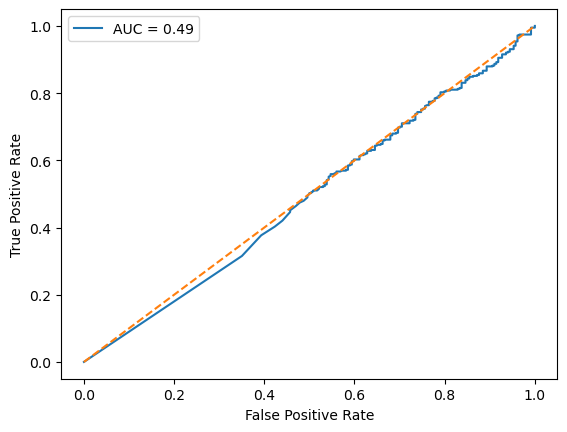

In [13]:
# ROC-AUC

from sklearn.metrics import roc_curve, auc

y_scores = []

for images, labels in test_data:
    preds = model.predict(images)
    y_scores.extend(preds.flatten())

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [21]:
model.save("pneumonia_cnn_v1.keras")
print("saved")

saved


In [23]:
img_size = (224, 224)

base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 


In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name="auc")]
)

In [29]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 2528s 15s/step - accuracy: 0.8236 - auc: 0.8547 - loss: 0.3973 - val_accuracy: 0.8141 - val_auc: 0.9528 - val_loss: 0.3464
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 2250s 13s/step - accuracy: 0.9178 - auc: 0.9694 - loss: 0.2115 - val_accuracy: 0.8301 - val_auc: 0.9630 - val_loss: 0.3328
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 4076s 25s/step - accuracy: 0.9367 - auc: 0.9786 - loss: 0.1735 - val_accuracy: 0.8750 - val_auc: 0.9665 - val_loss: 0.2767
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 2803s 17s/step - accuracy: 0.9423 - auc: 0.9822 - loss: 0.1544 - val_accuracy: 0.8894 - val_auc: 0.9697 - val_loss: 0.2683
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 1836s 11s/step - accuracy: 0.9503 - auc: 0.9853 - loss: 0.1400 - val_accuracy: 0.8862 - val_auc: 0.9726 - val_loss: 0.2724


In [31]:
y_true = []
y_pred = []
y_score = []

for images, labels in test_data:
    preds = model.predict(images)
    y_score.extend(preds.flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
[[168  66]
 [  5 385]]
              precision    recall  f1-score   support

      NORMAL       0.97      0.72      0.83       234
   PNEUMONIA       0.85      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      

In [33]:
print("AUC:", history.history["val_auc"][-1])

AUC: 0.9725783467292786


In [37]:
model.save("pneumonia_densenet_final.keras")
print("saved")

saved
